# Task 4 — Part B: Cross-Attention on Toy Data

Cross-attention is self-attention with one change: the **query** comes from one source (`x`) and the **keys/values** come from another (`context`). Here we verify shapes, visualize attention weights, and run a tiny training loop showing the mechanism learns to route information from a specific context position to a specific query position.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)


## The cross-attention modules

In [2]:
class CrossAttentionHead(nn.Module):
    def __init__(self, n_embd, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.last_attn = None

    def forward(self, x, context):
        q = self.query(x)        # (B, T_x, head_size)
        k = self.key(context)    # (B, T_c, head_size)
        v = self.value(context)  # (B, T_c, head_size)
        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)  # (B, T_x, T_c)
        wei = F.softmax(wei, dim=-1)
        self.last_attn = wei.detach()
        return wei @ v           # (B, T_x, head_size)

class MultiHeadCrossAttention(nn.Module):
    def __init__(self, n_embd, n_head, head_size):
        super().__init__()
        self.heads = nn.ModuleList([CrossAttentionHead(n_embd, head_size)
                                    for _ in range(n_head)])
        self.proj = nn.Linear(n_head * head_size, n_embd)

    def forward(self, x, context):
        out = torch.cat([h(x, context) for h in self.heads], dim=-1)
        return self.proj(out)


## Step 1-2 — Shapes

`x: (2, 10, 64)` (query length 10), `context: (2, 5, 64)` (context length 5). Output should be `(2, 10, 64)` — same length as the query.

In [3]:
x = torch.randn(2, 10, 64)
context = torch.randn(2, 5, 64)
mha = MultiHeadCrossAttention(n_embd=64, n_head=4, head_size=16)
out = mha(x, context)
print('x       :', tuple(x.shape))
print('context :', tuple(context.shape))
print('output  :', tuple(out.shape), '(== query length, not context length)')
assert out.shape == (2, 10, 64)


x       : (2, 10, 64)
context : (2, 5, 64)
output  : (2, 10, 64) (== query length, not context length)


## Step 3 — Attention heatmap (one head)

Rows = query positions (0-9), columns = context positions (0-4). Each row sums to 1.

row sums (should all be 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


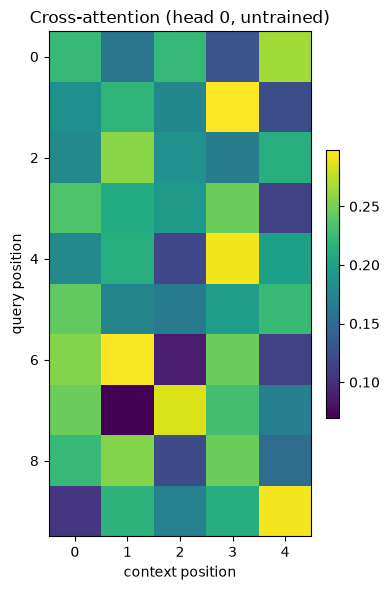

In [4]:
attn = mha.heads[0].last_attn[0]  # (T_x, T_c) for batch element 0
print('row sums (should all be 1):', attn.sum(-1))
fig, ax = plt.subplots(figsize=(4, 6))
im = ax.imshow(attn, cmap='viridis', aspect='auto')
ax.set_xlabel('context position'); ax.set_ylabel('query position')
ax.set_title('Cross-attention (head 0, untrained)')
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## Step 4 — Structured routing test

We set up a copy task: the cue vector at query position 5 is made identical to the vector at context position 2 (`x[:, 5] = context[:, 2]`), and the target output at position 5 is that same vector. **Crucially we redraw fresh random tensors every training step**, so the value at position 2 changes constantly — the model cannot memorize a fixed answer with its value/projection weights. The only way to drive the loss down is to genuinely *route*: match the query against the keys, find that position 2 is the match, and copy its value. After training, query position 5 should attend strongly to context position 2.

(A single fixed example would let the model cheat by baking the answer into its weights without ever sharpening the attention — randomizing the batch each step removes that shortcut.)

In [5]:
torch.manual_seed(0)
model = MultiHeadCrossAttention(n_embd=64, n_head=4, head_size=16)

def make_batch(B=16):
    x = torch.randn(B, 10, 64)
    context = torch.randn(B, 5, 64)
    x[:, 5] = context[:, 2]            # cue at query 5 matches context position 2
    target = context[:, 2].clone()    # output at position 5 should reproduce it
    return x, context, target

def q5_attention():
    # Mean over heads and batch of the attention from query position 5: shape (T_c,)
    return torch.stack([h.last_attn[:, 5] for h in model.heads]).mean(0).mean(0)

with torch.no_grad():
    xb, cb, _ = make_batch()
    model(xb, cb)
    before = q5_attention()
print('BEFORE  attention from q5 over context:', before.numpy().round(3))
print('        weight on position 2 =', round(before[2].item(), 3),
      '| argmax =', before.argmax().item())


BEFORE  attention from q5 over context: [0.201 0.19  0.209 0.192 0.208]
        weight on position 2 = 0.209 | argmax = 2


In [6]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(2000):
    xb, cb, tb = make_batch()
    out = model(xb, cb)
    loss = F.mse_loss(out[:, 5], tb)
    opt.zero_grad(); loss.backward(); opt.step()
print('final loss:', round(loss.item(), 6))

with torch.no_grad():
    xb, cb, _ = make_batch()
    model(xb, cb)
    after = q5_attention()
print('AFTER   attention from q5 over context:', after.numpy().round(3))
print('        weight on position 2 =', round(after[2].item(), 3),
      '| argmax =', after.argmax().item())
print('position 5 now strongly attends to position 2:',
      after.argmax().item() == 2 and after[2].item() > 0.5)


final loss: 0.003988
AFTER   attention from q5 over context: [0.003 0.002 0.988 0.004 0.003]
        weight on position 2 = 0.988 | argmax = 2
position 5 now strongly attends to position 2: True


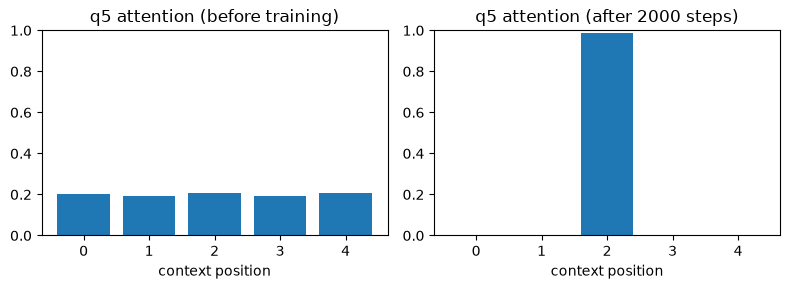

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, w, title in zip(axes, [before, after], ['before training', 'after 2000 steps']):
    ax.bar(range(5), w.numpy())
    ax.set_title(f'q5 attention ({title})'); ax.set_xlabel('context position')
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


---
**Conclusion.** Cross-attention can learn to route information from a chosen context position to a chosen query position. Because the answer always lives at context position 2 (and the values are re-randomized each step), query position 5's attention mass concentrates on position 2 after training — confirming the mechanism works before we wire it into the real multimodal model.
